# TP 3
Entrar el logotipo de la gaseosa dentro de las imágenes provistas en Material_TPs/TP3/images a partir del template Material_TPs/TP3/template


---
## 1. (4 puntos) Obtener una detección del logo en cada imagen sin falsos positivos


### Cargar las imagenes y verificar si hay imagenes que son más chicas que el pattern

In [94]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import imutils

def detectar_patron(imagen, patron, mostrar=True, metodo='cv.TM_CCOEFF', th1=50, th2=200, n=100):
    """
    Detecta un patrón (template) dentro de una imagen utilizando coincidencia de plantillas
    multiescala (template matching) y detección de bordes con Canny.

    El método aplica la plantilla sobre distintas escalas de la imagen de entrada para detectar
    patrones de distintos tamaños y mejora la robustez ante cambios de escala.

    Parámetros
    ----------
    imagen : np.ndarray
        Imagen de entrada en formato BGR.
    patron : np.ndarray
        Imagen plantilla a buscar dentro de la imagen de entrada.
    mostrar : bool, opcional
        Si es True, muestra la detección con un recuadro. Por defecto es True.
    metodo : str, opcional
        Método de coincidencia a usar. Debe ser un string de un método válido de cv2:
        'cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR', 'cv.TM_CCORR_NORMED',
        'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED'. Por defecto es 'cv.TM_CCOEFF'. Por defecto es 'cv.TM_CCOEFF'.
    th1 : int, opcional
        Umbral inferior de Canny. Por defecto 50.
    th2 : int, opcional
        Umbral superior de Canny. Por defecto 200.
    n : int, opcional
        Número de escalas a evaluar. Por defecto 100.

    Retorna
    -------
    tuple
        Coordenadas del rectángulo detectado (startX, startY, endX, endY) y valor de score.

    Notas
    -----
    No es invariante a rotaciones ni deformaciones. Para escenarios con rotaciones o
    cambios de perspectiva, se recomienda usar SIFT, ORB u otros descriptores locales.
    """

    imagen_color = imagen.copy()
    patron_color = patron.copy()

    metodo_iniciar = eval(metodo)  # Convertir string a método de OpenCV

    max_valor = -np.inf
    min_valor = np.inf
    mejor_match = None
    best_score = None

    # --- Paso 1: Procesamiento del patrón ---
    patron_gris = cv.cvtColor(patron_color, cv.COLOR_BGR2GRAY)
    patron_canny = cv.Canny(patron_gris, th1, th2)
    tH, tW = patron_canny.shape[:2]  # Alto y ancho del patrón

    # --- Paso 2: Convertir imagen de entrada a escala de grises ---
    imagen_gray = cv.cvtColor(imagen_color, cv.COLOR_BGR2GRAY)

    # --- Paso 3: Generar escalas para redimensionar la imagen ---
    patron_ancho = patron_gris.shape[1]
    min_scala = max(0.1, 100 / patron_ancho)  # Escala mínima
    max_scala = 1100 / patron_ancho           # Escala máxima
    escalas = np.linspace(min_scala, max_scala, n)[::-1]  # Escalas descendentes

    for escala in escalas:
        # Redimensionar imagen
        reajustado = imutils.resize(imagen_gray, width=int(imagen_gray.shape[1] * escala))
        r = imagen_gray.shape[1] / float(reajustado.shape[1])  # Factor de escala inverso

        # Saltar si el patrón no cabe en la imagen reescalada
        if reajustado.shape[0] < tH or reajustado.shape[1] < tW:
            continue

        # Detección de bordes sobre la imagen escalada
        bordes = cv.Canny(reajustado, th1, th2)

        # Coincidencia de plantilla
        resultado = cv.matchTemplate(bordes, patron_canny, metodo_iniciar)
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(resultado)

        # Selección de mejor resultado según el método
        if metodo_iniciar in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
            score = min_val
            if score < min_valor:
                min_valor = score
                mejor_match = (min_loc, r)
                best_score = score
        else:
            score = max_val
            if score > max_valor:
                max_valor = score
                mejor_match = (max_loc, r)
                best_score = score

    if mejor_match is None:
        print("No se encontró el patrón.")
        return None, None

    # --- Paso 4: Dibujar la mejor detección encontrada ---
    match_loc, r = mejor_match
    startX, startY = int(match_loc[0] * r), int(match_loc[1] * r)
    endX, endY = int((match_loc[0] + tW) * r), int((match_loc[1] + tH) * r)

    if mostrar:
        imagen_out = imagen_color.copy()
        cv.rectangle(imagen_out, (startX, startY), (endX, endY), (0, 255, 0), 4)
        plt.imshow(cv.cvtColor(imagen_out, cv.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

    return (startX, startY, endX, endY), best_score, metodo


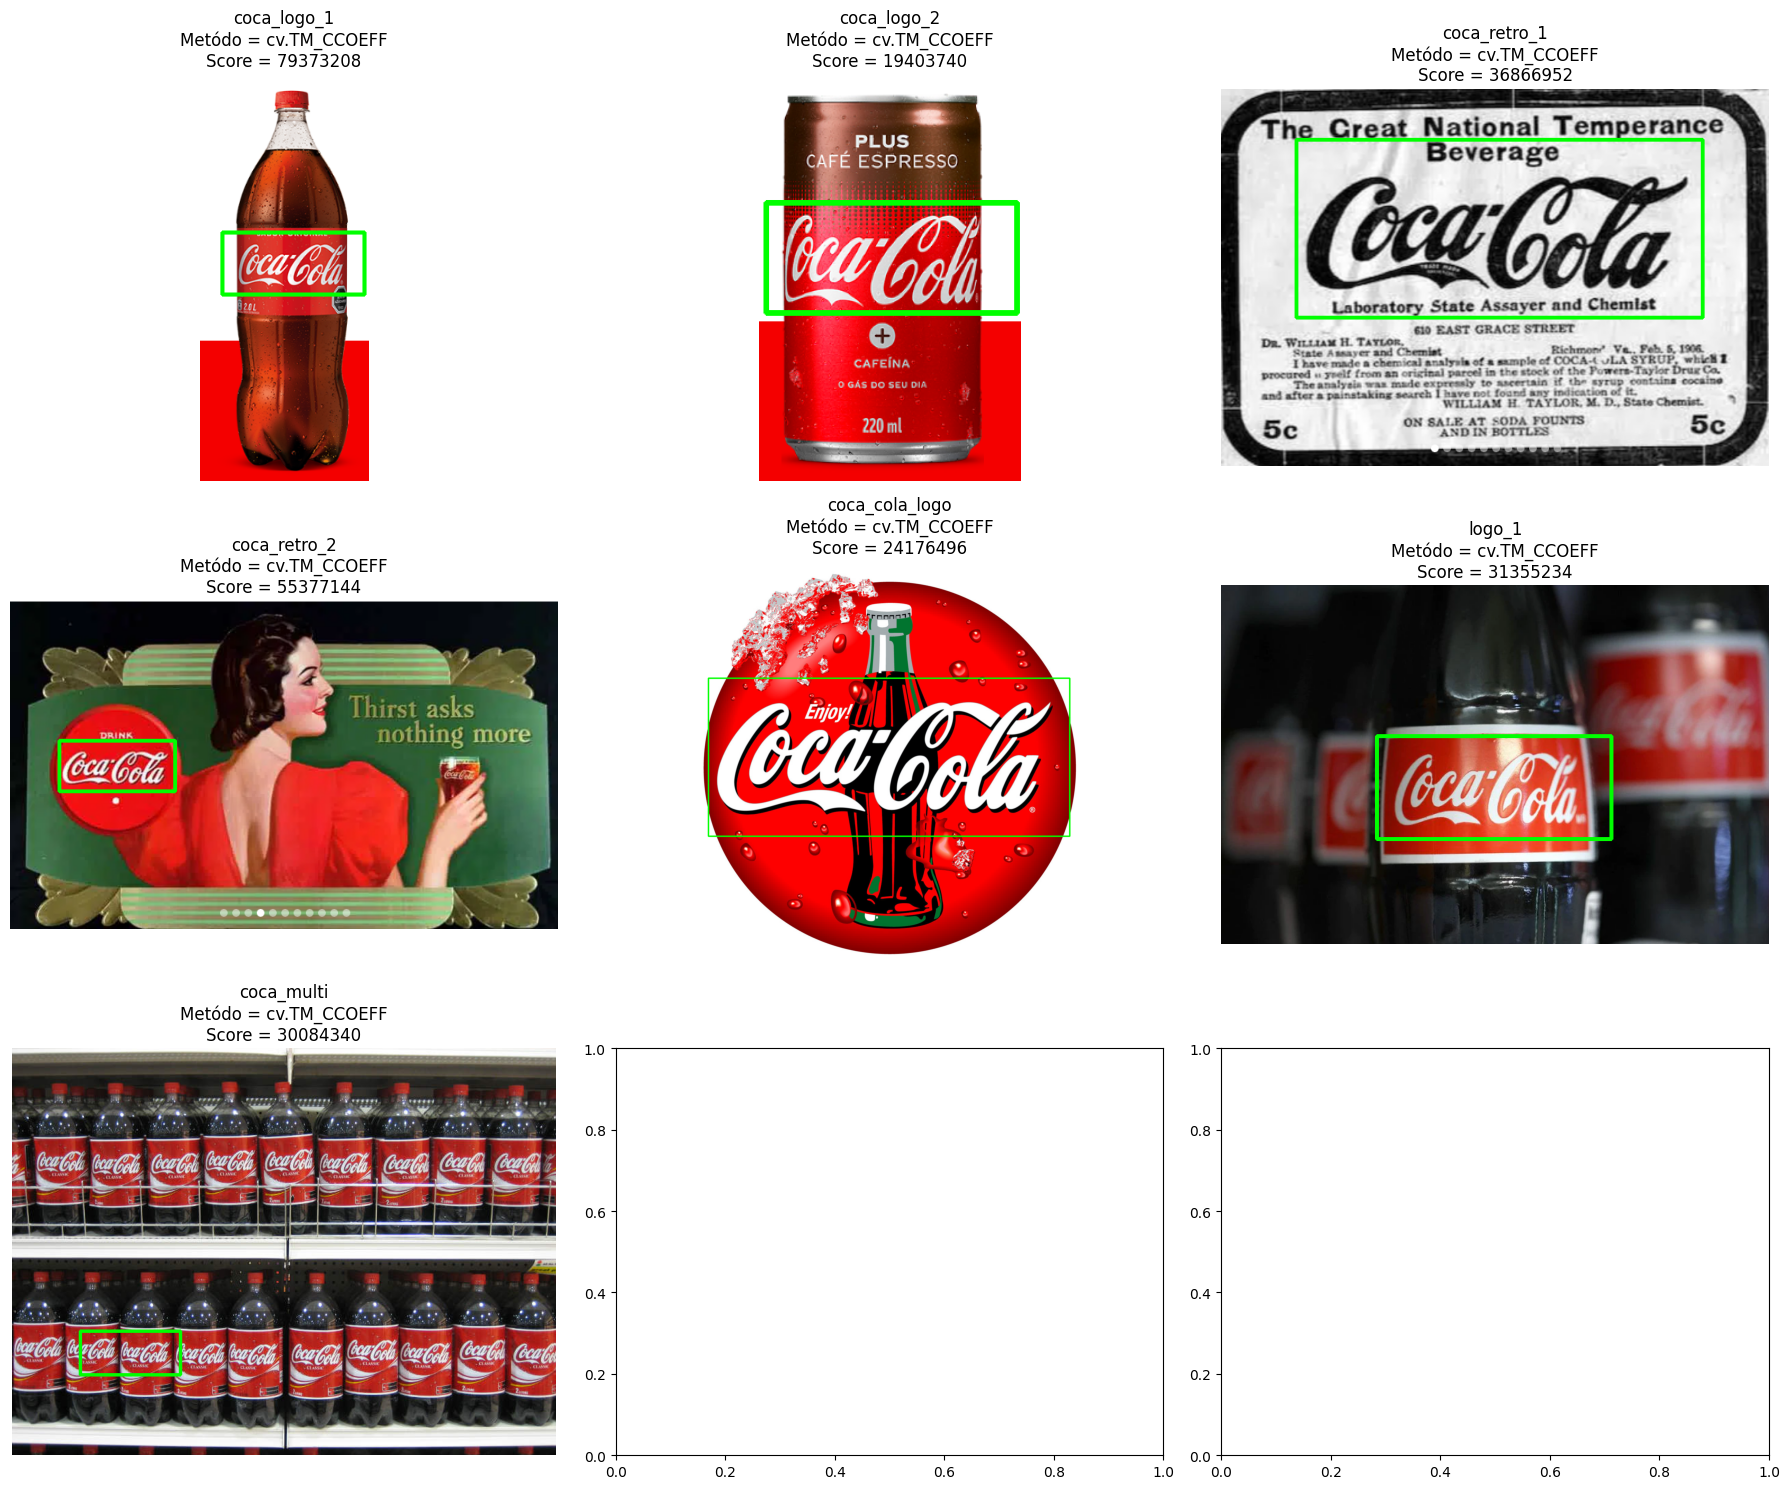

In [99]:
# El logotipo de la gaseosa
pattern = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/template/pattern.png')

# Cargar las imágenes en RGB y en escala de grises
coca_logo_1 = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/coca_logo_1.png')

coca_logo_2 = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/coca_logo_2.png')

coca_retro_1 = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/coca_retro_1.png')

coca_retro_2 = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/coca_retro_2.png')

coca_cola_logo = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/COCA-COLA-LOGO.jpg')

logo_1 = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/logo_1.png')

coca_multi = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/coca_multi.png')

# Aplicación del detector de patrones
import matplotlib.pyplot as plt
import cv2 as cv

# Lista de imágenes (nombre, imagen)
imagenes = [
    ("coca_logo_1", coca_logo_1),
    ("coca_logo_2", coca_logo_2),
    ("coca_retro_1", coca_retro_1),
    ("coca_retro_2", coca_retro_2),
    ("coca_cola_logo", coca_cola_logo),
    ("logo_1", logo_1),
    ("coca_multi", coca_multi),
]

# Crear figura para subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15)) 
axes = axes.ravel() 

for idx, (nombre, imagen) in enumerate(imagenes):
    box, score, method = detectar_patron(imagen, pattern, mostrar=False)
    imagen_out = imagen.copy()

    if box:
        startX, startY, endX, endY = box
        cv.rectangle(imagen_out, (startX, startY), (endX, endY), (0, 255, 0), 3)
        title = f"{nombre}\nMetódo = {method}\nScore = {score:.0f}"
    else:
        title = f"{nombre}\nNo detectado"

    imagen_rgb = cv.cvtColor(imagen_out, cv.COLOR_BGR2RGB)
    axes[idx].imshow(imagen_rgb)
    axes[idx].set_title(title)
    axes[idx].axis("off")

# Ajuste final
plt.tight_layout()
plt.show()


---
## 2. (4 puntos) Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1

In [ ]:
# -*- coding: utf-8 -*-
"""
Módulo para detección de logos usando template matching multiescala
con supresión no máxima (NMS) para evitar solapamientos.
"""

# --- 1. Importaciones ---
# Importa bibliotecas: OpenCV (cv), NumPy (np) y Matplotlib (plt).
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# --- 2. Función principal ---
def detectar_logos(imagen, patron, umbral=0.15, umbral_nms=0.3, mostrar=True):
    """
    Detecta múltiples ocurrencias de un patrón en una imagen usando coincidencia de plantillas
    en múltiples escalas y aplica supresión no máxima (NMS).

    Parámetros:
        imagen (np.ndarray): Imagen en formato BGR donde buscar el patrón.
        patron (np.ndarray): Imagen patrón (template) también en formato BGR.
        umbral (float): Valor mínimo de coincidencia (TM_CCOEFF_NORMED) para
                        considerar una detección candidata. Predeterminado: 0.15.
        umbral_nms (float): Umbral de superposición IoU para aplicar NMS.
                            Valores bajos suprimen más. Predeterminado: 0.3.
        mostrar (bool): Si es True, muestra la imagen con detecciones finales.
                        Predeterminado: True.

    Retorna:
        tuple:
            img_resultado (np.ndarray): Imagen (copia) con las detecciones marcadas.
            detectado (bool): True si hubo al menos una detección tras NMS.

    Lanza:
        ValueError: Si la imagen o el patrón son None.
    """

    # --- 3. Validación de entrada ---
    # Verifica que las imágenes de entrada existan.
    if imagen is None or patron is None:
        raise ValueError("La imagen o el patrón no pueden ser None.")

    # --- 4. Preparación de imágenes ---
    # Crea copia de la imagen original para dibujar resultados.
    imagen_color = imagen.copy()
    # Convierte imágenes a escala de grises para procesamiento.
    imagen_gris = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY)
    patron_gris = cv.cvtColor(patron, cv.COLOR_BGR2GRAY)
    # Obtiene dimensiones base del patrón para escalar.
    alto_patron, ancho_patron = patron_gris.shape

    # --- 5. Preprocesamiento de imágenes ---
    # Define función auxiliar para preprocesar imágenes en grises.
    def preprocesar(img_gris):
        """Aplica normalización, filtrado bilateral y detección de bordes (Canny)."""
        # Normaliza el contraste de la imagen.
        imagen_norm = cv.normalize(img_gris, None, 0, 255, cv.NORM_MINMAX)
        # Aplica filtro bilateral para suavizar ruido preservando bordes.
        imagen_filtrada = cv.bilateralFilter(imagen_norm, 9, 75, 75)
        # Detecta bordes usando el algoritmo Canny.
        return cv.Canny(imagen_filtrada, 50, 200)

    # Preprocesa la imagen principal (donde se buscará).
    imagen_procesada = preprocesar(imagen_gris)

    # --- 6. Búsqueda multiescala del patrón ---
    # Inicializa listas para guardar cajas (x,y,w,h) y puntajes candidatos.
    cajas, puntajes = [], []
    # Itera sobre un rango de escalas definidas.
    for escala in np.linspace(0.25, 2.5, 20):

        # Calcula dimensiones para la escala actual.
        ancho = int(ancho_patron * escala)
        alto = int(alto_patron * escala)
        # Evita dimensiones inválidas.
        if ancho <= 0 or alto <= 0:
            continue

        # Redimensiona el patrón en gris a la escala actual.
        patron_esc = cv.resize(patron_gris, (ancho, alto), interpolation=cv.INTER_AREA)

        # Verifica si el patrón redimensionado cabe en la imagen.
        if patron_esc.shape[0] > imagen_procesada.shape[0] or patron_esc.shape[1] > imagen_procesada.shape[1]:
            continue

        # Aplica preprocesamiento al patrón redimensionado.
        patron_proc = preprocesar(patron_esc)
        # Verifica si el preprocesamiento generó una imagen válida.
        if patron_proc is None or patron_proc.size == 0:
            continue

        # Realiza coincidencia de plantillas (TM_CCOEFF_NORMED).
        try:
            resultado = cv.matchTemplate(imagen_procesada, patron_proc, cv.TM_CCOEFF_NORMED)
        except cv.error:
            # Omite esta escala si matchTemplate falla.
            continue

        # Encuentra ubicaciones donde la coincidencia supera el umbral inicial.
        posiciones = np.where(resultado >= umbral)

        # Almacena las cajas y puntuaciones candidatas para NMS.
        # El formato de caja es (x_esquina_sup_izq, y_esquina_sup_izq, ancho, alto).
        for x, y in zip(posiciones[1], posiciones[0]):
            cajas.append((x, y, ancho, alto))
            puntajes.append(float(resultado[y, x])) 

    # --- 7. Aplicación de supresión no máxima (NMS) ---
    if not cajas:
        print("No se encontraron coincidencias iniciales que superen el umbral.")
        return imagen_color, False

    print(f"Se encontraron {len(cajas)} candidatos iniciales. Aplicando NMS...")
    # Aplica NMS para eliminar cajas redundantes basadas en IoU.
    try:
        # NMSBoxes devuelve los índices de las cajas a conservar.
        indices = cv.dnn.NMSBoxes(cajas, puntajes, score_threshold=0.0, nms_threshold=umbral_nms)
        if isinstance(indices, np.ndarray):
            indices = indices.flatten()
        # Si NMS no devuelve nada (posiblemente porque todas fueron suprimidas)
        elif indices is None or not isinstance(indices, (list, np.ndarray)):
             indices = []

    except Exception as e:
        print(f"Error durante la ejecución de NMS: {e}. No se mostrarán detecciones.")
        indices = [] 

    print(f"Número de detecciones después de NMS: {len(indices)}")

    # --- 8. Dibujo de las cajas resultantes ---
    for i in indices:
        x, y, w, h = cajas[i]
        cv.rectangle(imagen_color, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # --- 9. Visualización de resultados ---
    if mostrar:
        plt.figure(figsize=(10, 10))
        titulo = f"Resultado con {len(indices)} Detecciones (Post-NMS)"
        plt.imshow(cv.cvtColor(imagen_color, cv.COLOR_BGR2RGB))
        plt.title(titulo)
        plt.axis('off') 
        plt.show()

    # --- 10. Retorno final ---
    # Retorna la imagen con las cajas dibujadas y un booleano indicando si hubo detecciones finales.
    return imagen_color, len(indices) > 0


Se encontraron 109 candidatos iniciales. Aplicando NMS...
Número de detecciones después de NMS: 17


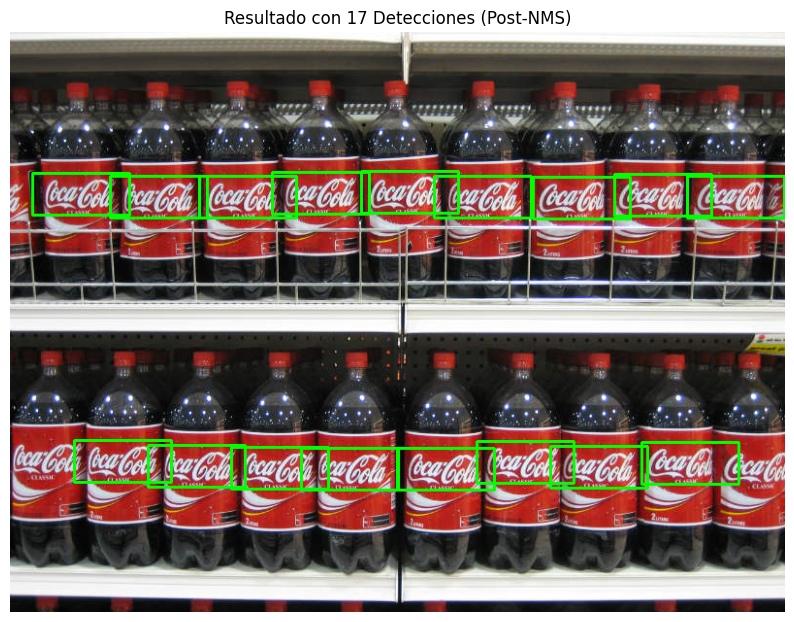

In [8]:

# El logotipo de la gaseosa
pattern = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/template/pattern.png')

# Cargar la imágen con múltiples logos
coca_multi = cv.imread('C:/Users/adria/OneDrive/Documentos/GitHub/vision_computadora_I/Material_TPs/TP3/images/coca_multi.png')

# Aplicar la detección de logos
resultado, hay_deteccion = detectar_logos(coca_multi, pattern)